In [41]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
from scipy.stats import percentileofscore

In [2]:
#print all csv files from the allocation_by_district folder
#note: not in order!
# glob.glob('./allocation_by_district/*.csv')

#alt method for printing all the files...
for files in glob.glob("*.csv"):
    print(files) 

alt_map.csv
census.csv
enacted_map.csv


In [3]:
# path is a string for the path of the folder we want to check
# path = os.getcwd() + '/allocation_by_county'
path = os.getcwd() + '/allocation_by_district'

#list of all filenames in the path which end in .csv
csv_files = glob.glob(os.path.join(path, "*.csv")) 
num_files = len(csv_files) #count of all files

# file_name = './allocation_by_county/seed_{}_by_county.csv'
file_name = './allocation_by_district/seed_{}_by_district.csv'
df_list = []
for i in range(num_files):
   iter_number=str(i).rjust(3,'0')
   df_list.append(pd.read_csv(file_name.format(iter_number)))


In [4]:
df=pd.read_csv('./allocation_by_district/seed_000_by_district.csv')
df.head()

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((325806.7526410533 4617405.525501856,...",790938,372444.169336,4.728577e+06,1,5.205925e+10,1.520782e+06,0.282862,196808.630282,0.427819
1,POLYGON ((299099.54163576674 4529226.381343519...,805940,327097.814266,4.596430e+06,2,2.053676e+10,1.019181e+06,0.248450,134906.014493,0.359186
2,"POLYGON ((530528.6206347387 4493399.353433513,...",788707,524544.364344,4.570685e+06,3,4.652257e+10,1.297989e+06,0.347002,202190.998226,0.362235
3,POLYGON ((605837.8838751405 4635240.0353934495...,804784,615374.058472,4.721685e+06,4,2.657951e+10,9.930376e+05,0.338708,159407.355618,0.332951


In [5]:
full_nestedlist=[]
for j in range(num_files):
    temp_df = df_list[j]
    list_for_j=[j, temp_df.loc[0,'Reock'],temp_df.loc[1,'Reock'],temp_df.loc[2,'Reock'],temp_df.loc[3,'Reock'],
                temp_df['Reock'].min(),temp_df['Reock'].max(),temp_df['Reock'].mean(),
    temp_df.loc[0,'PolsbyPopper'],temp_df.loc[1,'PolsbyPopper'],
    temp_df.loc[2,'PolsbyPopper'],temp_df.loc[3,'PolsbyPopper'],
                temp_df['PolsbyPopper'].min(),temp_df['PolsbyPopper'].max(),temp_df['PolsbyPopper'].mean(),
    temp_df['population'].min(),temp_df['population'].max()
    ]
    full_nestedlist.append(list_for_j)

# full_nestedlist


In [6]:
column_dict=[
    'seed',
    'Reock_d1',
    'Reock_d2',
    'Reock_d3',
    'Reock_d4',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_d1',
    'PP_d2',
    'PP_d3',
    'PP_d4',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [7]:
compactness_data_df = pd.DataFrame(full_nestedlist,columns=column_dict)

In [8]:
column_dict_analysis=[
    'seed',
    'Reock_min',
    'Reock_max',
    'Reock_mean',
    'PP_min',
    'PP_max',
    'PP_mean',
    'min_pop',
    'max_pop']

In [9]:
compactness_analysis_df = compactness_data_df[column_dict_analysis]
compactness_analysis_df

,seed,Reock_min,Reock_max,Reock_mean,PP_min,PP_max,PP_mean,min_pop,max_pop
0,0,0.332951,0.427819,0.370548,0.248450,0.347002,0.304255,788707,805940
1,1,0.448682,0.567162,0.508731,0.338438,0.498848,0.435282,791513,802747
2,2,0.361399,0.510667,0.447749,0.258152,0.448787,0.374006,357891,1259047
3,3,0.428981,0.562479,0.490348,0.294441,0.384121,0.339815,791071,804852
4,4,0.334623,0.470270,0.417341,0.279986,0.503789,0.401802,787989,806571
...,...,...,...,...,...,...,...,...,...
255,255,0.377538,0.521105,0.442242,0.299119,0.496623,0.403687,786876,808747
256,256,0.401156,0.501474,0.445208,0.355950,0.491336,0.410126,787180,804198
257,257,0.347251,0.471203,0.416687,0.330434,0.417375,0.367020,793050,803696
258,258,0.448234,0.609830,0.514783,0.437062,0.480777,0.469487,781197,816294


In [10]:
compactness_analysis_df.to_csv('./data/compactness_scores_simulations.csv', index=False, header=True)

In [11]:
#show all rows instead of first 5/last 5
# pd.set_option('display.max_rows', None)
# compactness_analysis_df

#reset max_rows:
# pd.reset_option(“max_rows”)

In [12]:
enacted_map=pd.read_csv('enacted_map.csv')
enacted_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((597046.3063824802 4495965.241673183,...",797584,655223.617473,4.626175e+06,1,2.847289e+10,1.120709e+06,0.284876,160047.768111,0.353820
1,"POLYGON ((558251.4820985557 4634182.10198691, ...",797589,631594.469070,4.793646e+06,2,3.361224e+10,1.004718e+06,0.418426,141576.968905,0.533780
2,POLYGON ((413996.78923838487 4491953.713269984...,797551,376909.476792,4.576509e+06,3,2.782373e+10,9.971415e+05,0.351651,144824.951242,0.422259
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797645,341387.505752,4.616499e+06,4,5.578923e+10,1.595846e+06,0.275282,191597.504183,0.483750


In [13]:
alternate_map=pd.read_csv('alt_map.csv')
alternate_map

,geometry,population,xcentr_lon,ycentr_lat,DISTRICT,area,perimeter,PolsbyPopper,min_bounding_radius,Reock
0,"POLYGON ((659405.8034389731 4506627.439222173,...",797655,655223.617473,4.626175e+06,1,1.669426e+10,8.095316e+05,0.320118,116372.651805,0.392388
1,"POLYGON ((568721.6887085006 4527942.280230374,...",797556,631594.469070,4.793646e+06,2,4.045878e+10,1.265121e+06,0.317657,155907.333430,0.529822
2,POLYGON ((452694.19555372297 4492297.318383798...,797584,357154.753953,4.543364e+06,3,2.260122e+10,8.294785e+05,0.412792,136323.573265,0.387115
3,"POLYGON ((299084.9524567265 4528678.815421122,...",797574,376909.476792,4.576509e+06,4,6.594382e+10,1.557147e+06,0.341763,226406.411288,0.409493


In [14]:
# map_dict = { 'map': ['enacted', 'alternate']
#             , 'Reock_min': [enacted_map['Reock'].min(), alternate_map['Reock'].min()]
#             , 'Reock_mean':[enacted_map['Reock'].mean(), alternate_map['Reock'].mean()]
#             , 'PP_min': [enacted_map['PolsbyPopper'].min(), alternate_map['PolsbyPopper'].min()]
#             , 'PP_mean':[enacted_map['PolsbyPopper'].mean(), alternate_map['PolsbyPopper'].mean()]
# }

map_dict = { 'measure': ['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean']
            , 'enacted': [enacted_map['Reock'].min(),enacted_map['Reock'].mean(),enacted_map['PolsbyPopper'].min(),enacted_map['PolsbyPopper'].mean()]
            , 'alternate': [alternate_map['Reock'].min(),alternate_map['Reock'].mean(), alternate_map['PolsbyPopper'].min(),alternate_map['PolsbyPopper'].mean() ]}

In [15]:
maps_df=pd.DataFrame(map_dict)
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


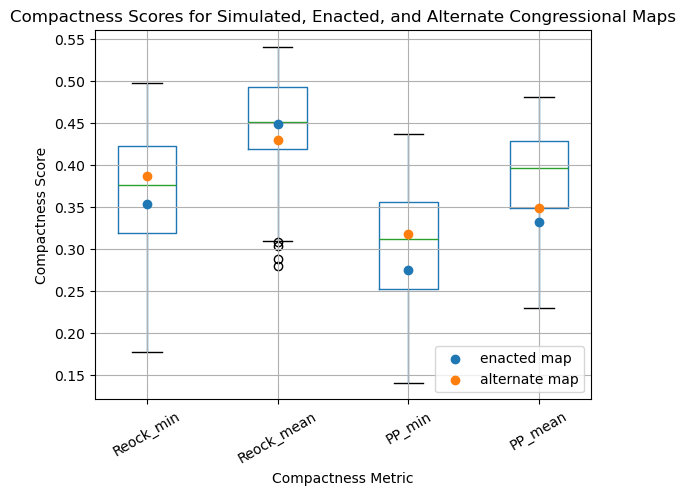

In [16]:
x = maps_df['measure']
y = maps_df['enacted']
b = maps_df['alternate']

compactness_analysis_df.boxplot(column=['Reock_min', 'Reock_mean', 'PP_min', 'PP_mean'], rot=30, zorder=1, positions=range(4))
plt.scatter(x=x, y=y, label='enacted map', zorder=2)
plt.scatter(x=x, y=b, label='alternate map', zorder=3)
plt.xlabel('Compactness Metric')
plt.ylabel('Compactness Score')
plt.title('Compactness Scores for Simulated, Enacted, and Alternate Congressional Maps')
plt.legend(loc='lower right')
# maps_df.plot.scatter(x='measure', y='enacted', zorder=2)
plt.show()
# maps_df.plot.scatter(column=['Reock_min', 'Reock_mean', 'PP_mean', 'PP_min'], zorder=2)

#Need to edit the off set

Regarding above boxplots, the enacted map is at or below the median for all metrics. The least compact alternate map district is more optimally compact than the least compact enacted district. Additionallly, the least compact alternate district is above the median for both metrics. 

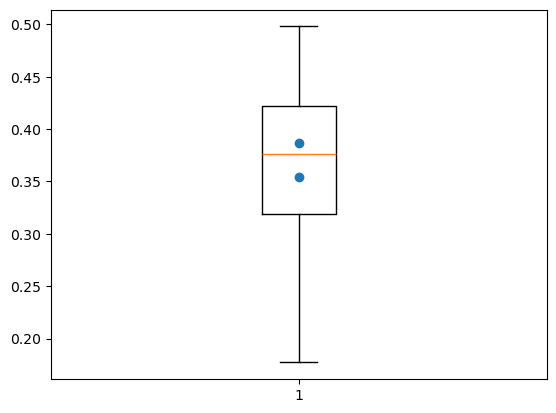

In [17]:
reock_min=maps_df.loc[maps_df['measure']=='Reock_min'][['enacted', 'alternate']]
plt.boxplot(x=compactness_analysis_df['Reock_min'], zorder=1)
plt.scatter(x=[1,1], y=reock_min, zorder=2)
plt.show()


In [35]:
reock_min_array=compactness_analysis_df['Reock_min'].to_numpy()
reock_mean_array=compactness_analysis_df['Reock_mean'].to_numpy()
pp_min_array=compactness_analysis_df['PP_min'].to_numpy()
pp_mean_array=compactness_analysis_df['PP_mean'].to_numpy()

In [37]:
maps_df

,measure,enacted,alternate
0,Reock_min,0.353820,0.387115
1,Reock_mean,0.448402,0.429705
2,PP_min,0.275282,0.317657
3,PP_mean,0.332559,0.348082


In [27]:
maps_df.iloc[0]['enacted']

0.3538200604788532

In [47]:
#reock min percentile for enacted
print('Reock min percentile for enacted is', percentileofscore(reock_min_array, maps_df.iloc[0]['enacted']))

#reock min percentile for alternate
print('Reock min percentile for alternate is ', percentileofscore(reock_min_array, maps_df.iloc[0]['alternate']))

print('Reock mean percentile for enacted is',percentileofscore(reock_mean_array, maps_df.iloc[1]['enacted']) )

print('Reock mean percentile for alternate is',percentileofscore(reock_mean_array, maps_df.iloc[1]['alternate']) )

print('Polsby-Popper min percentile for enacted is', percentileofscore(pp_min_array, maps_df.iloc[2]['enacted']))

#reock min percentile for alternate
print('Polsby-Popper min percentile for alternate is ', percentileofscore(pp_min_array, maps_df.iloc[2]['alternate']))

print('Polsby-Popper mean percentile for enacted is', percentileofscore(pp_mean_array, maps_df.iloc[3]['enacted']))

#reock min percentile for alternate
print('Polsby-Popper mean percentile for alternate is ', percentileofscore(pp_mean_array, maps_df.iloc[3]['alternate']))

Reock min percentile for enacted is 37.69230769230769
Reock min percentile for alternate is  59.61538461538462
Reock mean percentile for enacted is 46.53846153846154
Reock mean percentile for alternate is 31.153846153846157
Polsby-Popper min percentile for enacted is 32.69230769230769
Polsby-Popper min percentile for alternate is  53.46153846153847
Polsby-Popper mean percentile for enacted is 16.923076923076923
Polsby-Popper mean percentile for alternate is  25.0
